In [1]:
import pandas as pd
import json
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import HumanMessage
from pydantic import BaseModel
from dotenv import load_dotenv
import importlib
import generated_normalization_func
import time
import os

In [2]:
load_dotenv()

True

In [3]:
class AgentState(TypedDict):
    file_path: str
    df_summary: dict
    generated_code: str
    final_df: pd.DataFrame
    error_message: str
    retry_count: int

In [4]:
def inspect_data(state: AgentState):
    """Loads CSV and extracts metadata for the LLM."""
    print("Inspecting CSV...")
    df = pd.read_csv(state['file_path'])
    summary = {
        "columns": list(df.columns),
        "dtypes": df.dtypes.astype(str).to_dict(),
        "samples": df.sample(2).to_dict(orient='records')
    }
    print("CSV Inspection Successful!\n")
    return {"df_summary": summary}

In [5]:
class FunctionSchema(BaseModel):
    function: str

In [6]:
def generate_code(state: AgentState):
    """LLM writes the Python transformation function."""
    if not state.get("error_message"):
        print("Generating Normalization code...")

    llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

    error_context = ""
    if state.get("error_message"):
        error_context = f"""
### PREVIOUS ERROR ENCOUNTERED:
The last version of the function failed with the following error/issue:
{state["error_message"]}

Here is the last version of the function:
{state["generated_code"]}

Please analyze the metadata again and fix the logic to ensure data is correctly extracted.
"""
    
    prompt = f"""
    You are a Senior Data Engineer specializing in Security Operations (SecOps). 
I have a raw vulnerability scanner CSV file. 

### INPUT DATA PROFILE:
{state["df_summary"]}

### TASK:
Write a Python function `normalize_data(df)` using Pandas that transforms this raw data into our "Zero-Touch" standardized schema.

### TARGET SCHEMA:
- **vuln_id**: Use CVE ID if present. Fallback to scanner-specific ID. If both missing, use None.
- **severity_raw**: The original severity string, converted to ALL UPPERCASE (e.g., 'high' -> 'HIGH').
- **ip**: The IP Address or null.
- **hostname**: hostname or null.
- **port**: The port number or null.
- **instance_id**: cloud instance id or null.
- **component**: The package or software name.
- **affected_version**: The version of the component.
- **cvss_score**: Float. (Extract from string if necessary).
- **cvss_vector**: String representation of CVSS vector.
- **description**: Summary of the vulnerability.
- **references**: MUST BE A LIST of strings. (If source is a comma/newline string, split it).


### CRITICAL CONSTRAINTS:
1. **Handle Missing Columns**: If a column needed for the schema doesn't exist in the input, initialize it with `None` or appropriate defaults (False for booleans).
2. **Handle Nested Lists**: Scanners like Trivy/Grype often put multiple references in one cell. You must ensure the 'references' column in the output is a Python list for every row.
3. **Data Type Casting**: Explicitly cast numeric columns to `float` or `int` and boolean columns to `bool` to prevent 'object' dtype issues.
4. **Robustness**: Use `.get()` or `np.where()` logic to avoid `KeyError` if a column name is slightly different than expected in the sample.

### OUTPUT:
The function should return a new dataframe containing the standardized outputs
Return ONLY the Python code for the function `normalize_data(df)`. No explanations.
                                              
{error_context}
"""
    
    response = llm.with_structured_output(FunctionSchema).invoke([HumanMessage(content = prompt)])
    # Basic extraction of code block from markdown
    code = response.function.replace("```python", "").replace("```", "").strip()
    print("Normalization Code Generation Successful!\n")
    return {"generated_code": code, "retry_count": state["retry_count"] + 1}

In [7]:
def save_generated_code(state: AgentState):
    print("Saving Generated Code...")
    with open("generated_normalization_func.py", "w") as f:
        f.write(state["generated_code"])
    print("Code Saved Successfully!\n")
    return {}

In [8]:
def execute_generated_code(state: AgentState):
    print("Executing Code...")
    time.sleep(1)
    try:
        # Import and execute logic (from your execute_parse_code)
        spec = importlib.util.spec_from_file_location("dynamic_mod", "generated_normalization_func.py")
        module = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(module)
        
        df = module.normalize_data(pd.read_csv(state["file_path"]))
        
        # Validation Check: Is the DF empty?
        if df is None or df.empty:
            print("Execution successful, but the resulting data is EMPTY. Modifying normalization code...")
            return {
                "error_message": "Execution successful, but the resulting DataFrame is EMPTY. Ensure you are targeting the correct nested keys.",
                "final_df": df
            }
        print("Normalization Code Execution Successfull!\n")
        time.sleep(1)
        return {"final_df": df, "error_message": "SUCCESS"}

    except Exception as e:
        return {
            "error_message": f"Runtime Error: {str(e)}",
            "final_df": None
        }

In [9]:
def should_retry(state: AgentState):
    # Stop if successful
    if state.get("error_message") == "SUCCESS":
        return "Success/Retry Limit Exceeded"
    
    # Stop if we've tried too many times (e.g., 5 retries)
    if state.get("retry_count", 0) >= 3:
        print("Max retries reached. Manual intervention required.")
        return "Success/Retry Limit Exceeded"
    
    # Otherwise, loop back to generation
    print(f"Validation failed: {state['error_message']}. Retrying...")
    return "Validation Failed"

In [10]:
graph = StateGraph(AgentState)

graph.add_node("inspect_data", inspect_data)
graph.add_node("generate_code", generate_code)
graph.add_node("save_generated_code", save_generated_code)
graph.add_node("execute_generated_code", execute_generated_code)

graph.add_edge(START, "inspect_data")
graph.add_edge("inspect_data", "generate_code")
graph.add_edge("generate_code", "save_generated_code")
graph.add_edge("save_generated_code", "execute_generated_code")
graph.add_conditional_edges("execute_generated_code", should_retry, {"Success/Retry Limit Exceeded": END, "Validation Failed": "generate_code"})

workflow = graph.compile()

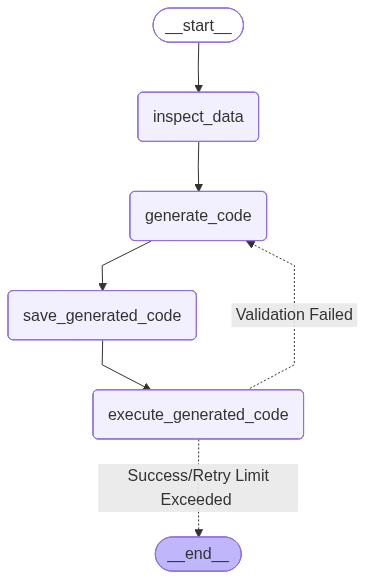

In [11]:
workflow

In [11]:
result = workflow.invoke({
    "file_path": "Parsed Outputs/grype_parsed.csv",
    "retry_count": 0
})

Inspecting CSV...
CSV Inspection Successful!

Generating Normalization code...
Normalization Code Generation Successful!

Saving Generated Code...
Code Saved Successfully!

Executing Code...
Normalization Code Execution Successfull!



In [13]:
# result['df_summary']

In [12]:
result['final_df']

,vuln_id,severity_raw,ip,hostname,port,instance_id,component,affected_version,cvss_score,cvss_vector,description,references
0,CVE-2023-4863,HIGH,None,None,None,None,pillow,5.4.1,8.8,CVSS:3.1/AV:N/AC:L/PR:N/UI:R/S:U/C:H/I:H/A:H,libwebp: OOB write in BuildHuffmanTable,[https://nvd.nist.gov/vuln/detail/CVE-2023-486...
1,CVE-2021-3749,HIGH,None,None,None,None,axios,0.19.0,7.5,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:N/I:N/A:H,axios Inefficient Regular Expression Complexit...,[https://nvd.nist.gov/vuln/detail/CVE-2021-374...
2,CVE-2023-32681,MEDIUM,None,None,None,None,requests,2.18.0,6.1,CVSS:3.1/AV:N/AC:H/PR:N/UI:R/S:C/C:H/I:N/A:N,Unintended leak of Proxy-Authorization header ...,[https://github.com/psf/requests/security/advi...
3,CVE-2019-16865,HIGH,None,None,None,None,pillow,5.4.1,7.5,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:N/I:N/A:H,DOS attack in Pillow when processing specially...,[https://nvd.nist.gov/vuln/detail/CVE-2019-168...
4,CVE-2019-10744,CRITICAL,None,None,None,None,lodash,4.17.4,9.1,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:N/I:H/A:H,Prototype Pollution in lodash,"[https://github.com/lodash/lodash/pull/4336, h..."
...,...,...,...,...,...,...,...,...,...,...,...,...
72,CVE-2025-13465,MEDIUM,None,None,None,None,lodash,4.17.4,6.5,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:N/I:L/A:L,Lodash has Prototype Pollution Vulnerability i...,[https://github.com/lodash/lodash/security/adv...
73,CVE-2026-2391,LOW,None,None,None,None,qs,6.7.0,3.7,CVSS:3.1/AV:N/AC:H/PR:N/UI:N/S:U/C:N/I:N/A:L,qs's arrayLimit bypass in comma parsing allows...,[https://github.com/ljharb/qs/security/advisor...
74,CVE-2026-27205,LOW,None,None,None,None,flask,0.12.0,2.3,CVSS:4.0/AV:N/AC:L/AT:P/PR:N/UI:P/VC:L/VI:N/VA...,Flask session does not add `Vary: Cookie` head...,[https://github.com/pallets/flask/security/adv...
75,GHSA-jgpv-4h4c-xhw3,MEDIUM,None,None,None,None,pillow,5.4.1,7.5,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:N/I:N/A:H,Uncontrolled Resource Consumption in pillow,[https://github.com/calix2/pyVulApp/security/a...


In [13]:
type(result['final_df'])

pandas.DataFrame

In [13]:
def save_dataframe_to_csv(df: pd.DataFrame, folder_path: str, file_name: str) -> str:
    """
    Save a pandas DataFrame to a CSV file in the specified folder.

    Args:
        df (pd.DataFrame): DataFrame to save.
        folder_path (str): Directory where the CSV will be stored.
        file_name (str): Name of the CSV file (e.g., 'data.csv').

    Returns:
        str: Full path of the saved CSV file.
    """
    # Create folder if it doesn't exist
    os.makedirs(folder_path, exist_ok=True)

    # Build full file path
    file_path = os.path.join(folder_path, file_name)

    # Save DataFrame to CSV
    df.to_csv(file_path, index=False)

    return file_path

In [ ]:
save_dataframe_to_csv(result['final_df'],"normalized_output","working.csv")

'Parsed Outputs\\working.csv'